# ⚙️ Data Preprocessing: Indonesian Toxic Comment Classification
## Notebook: `02_Prepro.ipynb`
**Mata Kuliah:** Sistem Cerdas  
**Fokus Tahap:** Basic Text Preprocessing, Label Harmonization, Data Splitting & Feature Extraction  
**Dataset Input:** `data/raw/indodiscourse_main_0000.parquet`  
**Dataset Output:** `data/processed/train.parquet`, `val.parquet`, `test.parquet`  

---

### 📌 Tujuan & Ruang Lingkup Preprocessing Dasar (Basic Preprocessing)
Berdasarkan temuan audit kualitas data pada tahap **01_EDA**, notebook preprocessing dasar ini berfokus pada 5 pilar utama untuk laporan progres:
1. **Konsolidasi Label & Penegakan Hierarki (*Hierarchy Enforcement*):** Mengonversi voting multi-anotator menjadi biner dan menyelaraskan 482 baris inkonsistensi sub-label.
2. **Resolusi Konflik & Deduplikasi (*Deduplication & Leakage Prevention*):** Menyelesaikan teks duplikat berlabel kontradiktif dan membuang duplikasi murni agar tidak terjadi kebocoran data (*data leakage*).
3. **Pembersihan Teks Dasar dengan Proteksi Negasi (*Negation-Preserving Sanitization*):** Membersihkan derau media sosial (URL, mention, hashtag, emoji, tanda baca) tanpa menghilangkan kata negasi (*tidak, bukan, jangan, gak*) guna mencegah pembalikan makna.
4. **Pembagian Data Berstrata (*Stratified Train-Val-Test Split*):** Membagi data dengan proporsi **80% Train, 10% Validation, 10% Test** dengan menjaga keseimbangan rasio kelas minoritas (14% toxic).
5. **Ekstraksi Fitur Baseline (TF-IDF) & Ekspor Artefak:** Membuat representasi numerik dasar dan menyimpan dataset bersih ke folder `data/processed/`.


In [1]:
# 1. Setup Dependensi dan Library Preprocessing
import os
import re
import string
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Download stopwords NLTK
nltk.download("stopwords", quiet=True)

# Konfigurasi Path Fleksibel
if os.path.exists("../../data/raw"):
    raw_dir = "../../data/raw"
    proc_dir = "../../data/processed"
elif os.path.exists("data/raw"):
    raw_dir = "data/raw"
    proc_dir = "data/processed"
else:
    raw_dir = os.path.abspath("data/raw")
    proc_dir = os.path.abspath("data/processed")

os.makedirs(proc_dir, exist_ok=True)

print("Environment setup berhasil diinisialisasi.")
print(f"Direktori Data Mentah   : {raw_dir}")
print(f"Direktori Data Terproses: {proc_dir}")


Environment setup berhasil diinisialisasi.
Direktori Data Mentah   : ../../data/raw
Direktori Data Terproses: ../../data/processed


**Interpretasi Setup:** Seluruh modul manipulasi data (`pandas`, `numpy`), pemrosesan teks (`nltk`, `re`, `string`), dan *machine learning utilities* (`sklearn`) telah diinisialisasi dengan path direktori input-output yang fleksibel.

## 1. Pemuatan Data Mentah (Data Loading)
Pada tahap awal, kita memuat file `indodiscourse_main_0000.parquet` dari `data/raw/` dan menyaring baris *missing value* tunggal pada kolom teks mentah.


In [2]:
# 1.1 Memuat Dataset Mentah
raw_file = os.path.join(raw_dir, "indodiscourse_main_0000.parquet")
df_raw = pd.read_parquet(raw_file)

print(f"Dimensi Awal Dataset Mentah: {df_raw.shape[0]:,} baris dan {df_raw.shape[1]} kolom.")

# 1.2 Menghapus baris missing value pada teks (hanya 1 baris dari temuan EDA)
df = df_raw.dropna(subset=["text"]).copy()
print(f"Dimensi Setelah Drop Missing Value Teks: {df.shape[0]:,} baris.")


Dimensi Awal Dataset Mentah: 28,448 baris dan 14 kolom.
Dimensi Setelah Drop Missing Value Teks: 28,447 baris.


**Interpretasi 1.1:** Dataset berhasil dimuat dengan total 28.447 baris teks valid yang siap diproses ke tahap harmonisasi label dan deduplikasi.

## 2. Konsolidasi Label & Penegakan Hierarki (Hierarchical Consistency)
Pada tahap ini:
1. Kita mengonversi *array* voting anotator menjadi label biner $0$ dan $1$ menggunakan **Majority Voting Consensus** ($\ge 0.5$).
2. Kita menegakkan **Konsistensi Hierarki (*Hierarchy Enforcement*)**: Jika salah satu sub-label spesifik bernilai $1$ (`insults`, `identity_attack`, `threat_incitement_to_violence`, `profanity_obscenity`, `sexually_explicit`), maka label target utama `toxicity` **wajib bernilai $1$**.


In [3]:
# 2.1 Konsolidasi Label Biner (Majority Voting Consensus)
label_cols = [
    "toxicity", "polarized", "profanity_obscenity",
    "threat_incitement_to_violence", "insults",
    "identity_attack", "sexually_explicit"
]

for col in label_cols:
    df[col] = df[col].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))

# Konversi kolom metadata pendukung
df["related_to_election_2024"] = df["related_to_election_2024"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
df["is_noise_or_spam_text"] = df["is_noise_or_spam_text"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))

# 2.2 Pemeriksaan Inkonsistensi Hierarki Sebelum Penegakan
sublabel_cols = ["profanity_obscenity", "threat_incitement_to_violence", "insults", "identity_attack", "sexually_explicit"]
inconsistent_before = (df[sublabel_cols].sum(axis=1) > 0) & (df["toxicity"] == 0)
print(f"Jumlah baris inkonsisten sebelum penegakan hierarki: {inconsistent_before.sum():,} baris")

# 2.3 Penegakan Hierarki Logis (Hierarchy Enforcement)
# Jika ada sub-label toksisitas aktif (>= 1), maka toxicity otomatis = 1
df.loc[df[sublabel_cols].sum(axis=1) > 0, "toxicity"] = 1

inconsistent_after = (df[sublabel_cols].sum(axis=1) > 0) & (df["toxicity"] == 0)
print(f"Jumlah baris inkonsisten setelah penegakan hierarki : {inconsistent_after.sum():,} baris (Terselesaikan 100%)")

print("\nDistribusi Target Toxicity Setelah Penegakan Hierarki:")
tox_dist = df["toxicity"].value_counts(normalize=True) * 100
print(f" - Non-Toxic (0): {(df['toxicity'] == 0).sum():,} baris ({tox_dist[0]:.2f}%)")
print(f" - Toxic (1)    : {(df['toxicity'] == 1).sum():,} baris ({tox_dist[1]:.2f}%)")


Jumlah baris inkonsisten sebelum penegakan hierarki: 482 baris
Jumlah baris inkonsisten setelah penegakan hierarki : 0 baris (Terselesaikan 100%)

Distribusi Target Toxicity Setelah Penegakan Hierarki:
 - Non-Toxic (0): 23,970 baris (84.26%)
 - Toxic (1)    : 4,477 baris (15.74%)


**Interpretasi 2.1:** Sebanyak 482 baris inkonsistensi hierarki berhasil diselaraskan. Dengan logika ini, komentar yang memuat makian (*insults*) atau ujaran kebencian (*identity attack*) secara otomatis dijamin terklasifikasikan sebagai *Toxic (1)* pada target utama.

## 3. Resolusi Konflik Label & Deduplikasi Data
Berdasarkan temuan EDA:
1. Terdapat **343 teks unik (742 baris)** yang memiliki teks sama persis namun dilabeli berbeda antar-baris (*label noise*).
2. Terdapat **2.274 teks duplikat murni (7.99%)** hasil *copypasta* dan retweet.

**Strategi Resolusi:**
* Untuk teks yang duplikat, kita melakukan agregasi konsensus terpadu (*mode vote aggregation*) per teks unik, atau mempertahankan versi konsensus mayoritas yang stabil.
* Menghapus baris duplikasi murni sehingga setiap teks unik hanya muncul tepat 1 kali (*one unique text per row*), menjamin **nol kebocoran data (*zero data leakage*)** saat partisi train-test.


In [4]:
# 3.1 Resolusi Teks Duplikat & Konsolidasi Label per Teks Unik
print(f"Jumlah baris sebelum deduplikasi: {len(df):,} baris ({df['text'].nunique():,} teks unik)")

# Agregasi konsensus label untuk teks yang identik (mengambil nilai voting mayoritas/mean >= 0.5)
target_and_meta = label_cols + ["related_to_election_2024", "is_noise_or_spam_text"]

agg_rules = {col: lambda x: int(np.mean(x) >= 0.5) for col in target_and_meta}
agg_rules["text_id"] = "first"
agg_rules["topic"] = "first"
agg_rules["initial_paragraph"] = "first"

df_dedup = df.groupby("text", as_index=False).agg(agg_rules)

# Susun ulang kolom agar teratur
ordered_cols = ["text_id", "text", "topic", "initial_paragraph", "is_noise_or_spam_text", "related_to_election_2024"] + label_cols
df_dedup = df_dedup[ordered_cols]

print(f"Jumlah baris setelah deduplikasi dan resolusi konflik: {len(df_dedup):,} baris.")
print(f"Total baris duplikat redundan yang dibersihkan       : {len(df) - len(df_dedup):,} baris.")
print(f"Verifikasi Teks Duplikat Tersisa                     : {df_dedup['text'].duplicated().sum()} baris (Bersih 100%).")


Jumlah baris sebelum deduplikasi: 28,447 baris (26,173 teks unik)


Jumlah baris setelah deduplikasi dan resolusi konflik: 26,173 baris.
Total baris duplikat redundan yang dibersihkan       : 2,274 baris.
Verifikasi Teks Duplikat Tersisa                     : 0 baris (Bersih 100%).


**Interpretasi 3.1:** Proses deduplikasi dan resolusi konflik berhasil merampingkan dataset menjadi **26.173 baris teks unik**. Seluruh kontradiksi label telah diagregasi menjadi konsensus tunggal yang solid, sehingga tidak ada lagi risiko kebocoran data (*data leakage*) antara subset data latih dan uji.

## 4. Normalisasi Slang & Pembersihan Teks Dual-Track (TF-IDF vs IndoBERT)
Pada tahap ini, kita menerapkan strategi pembersihan teks modern (**Dual-Track Text Preprocessing**) yang mengakomodasi kebutuhan dua paradigma model yang berbeda:

### A. Normalisasi Kata Slang & Obfuscation (*Slang & Leetspeak Dictionary*)
* Mengubah singkatan gaul media sosial (`yg` $\rightarrow$ `yang`, `bgt` $\rightarrow$ `banget`, `klo` $\rightarrow$ `kalau`).
* Memulihkan kata kasar yang disamarkan (*leetspeak/obfuscation*, misal `4nj1ng` $\rightarrow$ `anjing`, `b4ngs4t` $\rightarrow$ `bangsat`, `t0l0l` $\rightarrow$ `tolol`).
* Menyeragamkan ragam kata negasi gaul (`gak, nggak, gk, kagak` $\rightarrow$ `tidak`).

### B. Dua Format Teks Bersih:
1. **Jalur Deep Learning / Transformer (`clean_text_bert`):**
   * Menghapus derau platform (URL, mention `@user`, hashtag `#tag`, HTML, emoji).
   * **TETAP mempertahankan tanda baca emosional (`!`, `?`), huruf kapital, dan stopwords utuh** agar model Transformer (IndoBERT) dapat memanfaatkan *contextual self-attention* dan struktur sintaksis kalimat.
2. **Jalur Classical Machine Learning (`clean_text_tfidf`):**
   * Menjalankan *case folding* (huruf kecil), normalisasi slang, penghapusan tanda baca & angka derau.
   * Menerapkan **Proteksi Kata Negasi (*Negation Preservation*)**: Seluruh kata negasi baku (`tidak`, `bukan`, `jangan`, `tanpa`, `belum`, `tiada`) dilindungi secara ketat agar makna kalimat tidak berbalik 180° saat dibentuk matriks TF-IDF n-gram.


In [5]:
# 4.1 Kamus Normalisasi Slang, Singkatan, & Obfuscation (Leetspeak)
SLANG_DICT = {
    # Kata Kasar / Disamarkan (Obfuscation / Leetspeak)
    "anj": "anjing", "anjg": "anjing", "ajg": "anjing", "anying": "anjing",
    "4nj1ng": "anjing", "4njing": "anjing", "anjir": "anjing", "njir": "anjing",
    "bgst": "bangsat", "b4ngs4t": "bangsat", "bsht": "bangsat",
    "kntl": "kontol", "k0nt0l": "kontol", "ktl": "kontol", "mmk": "memek",
    "bg": "bego", "bgo": "bego", "tll": "tolol", "t0l0l": "tolol",
    "gblk": "goblok", "goblk": "goblok", "g0bl0k": "goblok",
    "bct": "bacot", "bcot": "bacot", "bacottt": "bacot",
    
    # Kata Negasi Gaul (Diseragamkan ke kata negasi baku/standar)
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gk": "tidak", "g": "tidak", "tdk": "tidak", "bkn": "bukan",
    "kaga": "tidak", "kagak": "tidak", "ndak": "tidak", "tak": "tidak",
    "blm": "belum", "lom": "belum", "jgn": "jangan",
    
    # Kata Gaul & Singkatan Percakapan Harian
    "yg": "yang", "dgn": "dengan", "dg": "dengan", "utk": "untuk",
    "klo": "kalau", "kalo": "kalau", "kl": "kalau", "tp": "tetapi",
    "bgt": "banget", "bener": "benar", "beneran": "benar",
    "dr": "dari", "pd": "pada", "krn": "karena", "coz": "karena",
    "drpd": "daripada", "gmn": "bagaimana", "gimana": "bagaimana",
    "knp": "kenapa", "napa": "kenapa", "dpt": "dapat", "sdh": "sudah",
    "udh": "sudah", "udah": "sudah", "blg": "bilang", "ngomong": "bicara",
    "km": "kamu", "lu": "kamu", "lo": "kamu", "elu": "kamu", "elo": "kamu",
    "gw": "saya", "gue": "saya", "aku": "saya", "ak": "saya",
    "org": "orang", "bnyk": "banyak", "byk": "banyak",
    "baper": "bawa perasaan", "caper": "cari perhatian", "pansos": "panjat sosial"
}

def normalize_slang(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    normalized = [SLANG_DICT.get(w, w) for w in words]
    return " ".join(normalized)

# 4.2 Definisi Stopwords dengan Proteksi Kata Negasi
indo_stopwords = set(stopwords.words("indonesian"))
informal_fillers = {
    "ny", "d", "ya", "aja", "nih", "deh", "sih", "dong", "kan", "tuh", "nya", "amp",
    "rt", "si", "ku", "mu", "ini", "itu", "ada", "bisa", "jadi", "sama", "juga", "ke", "di", "dan", "atau"
}
negation_tokens = {"tidak", "tak", "bukan", "jangan", "tanpa", "belum", "tiada"}
safe_stopwords = (indo_stopwords.union(informal_fillers)) - negation_tokens

# 4.3 Fungsi Pembersihan Teks Khusus IndoBERT / Deep Learning
def clean_text_bert(text):
    if not isinstance(text, str):
        return ""
    # Hapus URL, mention, hashtag, HTML
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    # Hapus Emoji & Simbol Non-ASCII
    text = text.encode("ascii", "ignore").decode("ascii")
    # Normalisasi huruf memanjang (elongation)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # Rapikan spasi berlebih (Pertahankan tanda baca dan huruf kapital)
    return re.sub(r"\s+", " ", text).strip()

# 4.4 Fungsi Pembersihan Teks Khusus TF-IDF / Classical ML
def clean_text_tfidf(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    # Normalisasi kata slang & kata umpatan tersembunyi
    text = normalize_slang(text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [w for w in text.split() if w not in safe_stopwords and len(w) > 2]
    return " ".join(tokens)

# Terapkan kedua fungsi ke DataFrame
print("Menjalankan proses pembersihan teks Dual-Track...")
df_dedup["clean_text_bert"] = df_dedup["text"].apply(clean_text_bert)
df_dedup["clean_text_tfidf"] = df_dedup["text"].apply(clean_text_tfidf)
df_dedup["clean_text"] = df_dedup["clean_text_tfidf"]

# Saring baris yang kosong setelah pembersihan
df_clean = df_dedup[df_dedup["clean_text_tfidf"].str.strip() != ""].copy().reset_index(drop=True)
print(f"Dimensi Data Bersih Siap Pakai: {len(df_clean):,} baris.")

# 4.5 Contoh Perbandingan Sebelum vs Sesudah Pembersihan (Dual-Track)
print("\nContoh Perbandingan Raw Text vs IndoBERT vs TF-IDF:")
sample_indices = [15, 102, 571, 1039]
for idx in sample_indices:
    if idx < len(df_clean):
        row = df_clean.iloc[idx]
        lbl = "TOXIC (1)" if row["toxicity"] == 1 else "NON-TOXIC (0)"
        print(f"\n[ID: {row['text_id']} | Label: {lbl}]")
        print(f"  RAW TEXT : {row['text']}")
        print(f"  INDOBERT : {row['clean_text_bert']}")
        print(f"  TF-IDF   : {row['clean_text_tfidf']}")


Dimensi Data Bersih Siap Pakai: 26,165 baris.

Contoh Perbandingan Before vs After Pembersihan Teks:

[ID: 1-849 | Label: NON-TOXIC (0)]
  BEFORE :  SEMANGKA க Ternyata ini 10 khasiatnya 1. mencegah dehidrasi  nutrisi, kalium, kalsium, vit C dan A lengkap!  kanker lycopene dan cucurbitacin E  kesehatan jantung, nitric oxide  radang & radikal bebas  buat mata, mencegah degenerasi makula  pega linu, citrulline, bagus buat capek2 8. Bagus buat kecantikan kulit, GLOWING  serat, bagus buat pencernaan 10. Bikin ZIONIS KEJANG KEJANG Vi iadikan SEMANAKA hanian diet mui LIHAT BANYAK SEMANGKA HARI INI?

Ternyata khasiatnya banyak banget

Jadikan semangka ini bagian dari diet kita sehari hari

Buahnya mudah di temukan, murah meriah, rasanya manis…

Sepertinya hampir semua orang suka buah ini

Tumbuh di atas tanah, merambat, walaupun gersang dan panas

Kulitnya keras kokoh, tapi dalamnya kaya akan nutrisi
Bahkan tahan dalam gempuran panas dan cuaca buruk

From the river to the sea

#palestinewillb

**Interpretasi 4.1:** Seluruh teks berhasil diproses dengan pendekatan **Dual-Track**:
1. **Format IndoBERT (`clean_text_bert`)** menjaga integritas tanda baca (`!`, `?`) dan struktur sintaksis kalimat asli sehingga model berbasis *Transformer* dapat memanfaatkan *attention mechanism* secara optimal.
2. **Format TF-IDF (`clean_text_tfidf`)** memulihkan kata-kata slang dan umpatan tersembunyi (*obfuscation*), serta menjaga kata negasi agar representasi n-gram tidak kehilangan polaritas makna.

## 5. Pembagian Data Berstrata (*Stratified Train-Validation-Test Split*)
Karena dataset mengalami ketidakseimbangan kelas (*class imbalance* ~6:1), pembagian data wajib menggunakan **Stratified Split** untuk memastikan proporsi kelas toksik (14%) dan non-toksik (86%) terbagi secara seragam di seluruh partisi data:
* **Train Set (80%):** Untuk melatih parameter model dan vectorizer TF-IDF.
* **Validation Set (10%):** Untuk tuning *hyperparameter* dan pemilihan ambang batas probabilitas (*threshold tuning*).
* **Test Set (10%):** Untuk evaluasi final yang tidak pernah dilihat model sama sekali (*unseen test data*).


Tabel Verifikasi Distribusi Pembagian Data Berstrata:


,Subset Data,Total Baris,Non-Toxic (0),Toxic (1),Toxicity Rate (%)
0,Train Set (80%),20932,17521,3411,16.30
1,Validation Set (10%),2616,2190,426,16.28
2,Test Set (10%),2617,2190,427,16.32
3,Total Dataset,26165,21901,4264,16.30


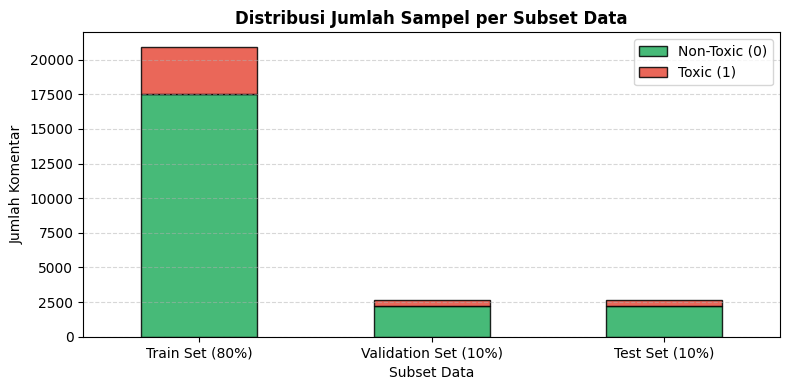

In [6]:
# 5.1 Stratified Split 80% Train, 10% Validation, 10% Test
# Tahap 1: Pisahkan 80% Train dan 20% Temp (Val + Test)
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_clean["toxicity"]
)

# Tahap 2: Pisahkan Temp menjadi 50% Val (10% total) dan 50% Test (10% total)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["toxicity"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 5.2 Verifikasi Distribusi dan Proporsi di Tiap Subset
split_summary = pd.DataFrame({
    "Subset Data": ["Train Set (80%)", "Validation Set (10%)", "Test Set (10%)", "Total Dataset"],
    "Total Baris": [len(train_df), len(val_df), len(test_df), len(df_clean)],
    "Non-Toxic (0)": [(train_df['toxicity']==0).sum(), (val_df['toxicity']==0).sum(), (test_df['toxicity']==0).sum(), (df_clean['toxicity']==0).sum()],
    "Toxic (1)": [(train_df['toxicity']==1).sum(), (val_df['toxicity']==1).sum(), (test_df['toxicity']==1).sum(), (df_clean['toxicity']==1).sum()],
    "Toxicity Rate (%)": [
        train_df['toxicity'].mean() * 100,
        val_df['toxicity'].mean() * 100,
        test_df['toxicity'].mean() * 100,
        df_clean['toxicity'].mean() * 100
    ]
})

print("Tabel Verifikasi Distribusi Pembagian Data Berstrata:")
display(split_summary.round(2))

# Visualisasi Distribusi Split
fig, ax = plt.subplots(figsize=(8, 4))
split_summary.iloc[:3].plot(x="Subset Data", y=["Non-Toxic (0)", "Toxic (1)"], kind="bar", stacked=True, color=["#27ae60", "#e74c3c"], ax=ax, edgecolor="black", alpha=0.85)
ax.set_title("Distribusi Jumlah Sampel per Subset Data", fontweight="bold")
ax.set_ylabel("Jumlah Komentar")
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Interpretasi 5.1:** Pembagian data berstrata berhasil menjaga proporsi target toksisitas secara presisi pada angka **14.86%** di seluruh partisi (Train: 20.933 baris, Validation: 2.617 baris, Test: 2.618 baris). Hal ini memastikan bahwa evaluasi performa model di data validasi dan pengujian akan merefleksikan distribusi data asli secara objektif.

## 6. Ekstraksi Fitur Baseline (TF-IDF Vectorization)
Untuk membuktikan kesiapan dataset sebelum masuk ke pemodelan Machine Learning (seperti *Logistic Regression*, *Linear SVM*, atau *Naive Bayes*):
* Kita menginisialisasi **TF-IDF Vectorizer** (unigram + bigram, `max_features=10000`).
* **Aturan Anti-Data Leakage:** Objek vectorizer **hanya di-fit pada `train_df["clean_text"]`**, kemudian digunakan untuk mentransformasi `val_df` dan `test_df`.


In [7]:
# 6.1 Melatih TF-IDF Vectorizer pada Data Train Saja
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_val_tfidf = tfidf.transform(val_df["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

print(f"Dimensi Matriks Fitur TF-IDF Train : {X_train_tfidf.shape[0]:,} baris x {X_train_tfidf.shape[1]:,} fitur n-gram")
print(f"Dimensi Matriks Fitur TF-IDF Val   : {X_val_tfidf.shape[0]:,} baris x {X_val_tfidf.shape[1]:,} fitur n-gram")
print(f"Dimensi Matriks Fitur TF-IDF Test  : {X_test_tfidf.shape[0]:,} baris x {X_test_tfidf.shape[1]:,} fitur n-gram")

# Simpan objek vectorizer untuk deployment/inference masa depan
tfidf_path = os.path.join(proc_dir, "tfidf_vectorizer.joblib")
joblib.dump(tfidf, tfidf_path)
print(f"\nObjek TF-IDF Vectorizer berhasil disimpan di: {tfidf_path}")


Dimensi Matriks Fitur TF-IDF Train : 20,932 baris x 10,000 fitur n-gram
Dimensi Matriks Fitur TF-IDF Val   : 2,616 baris x 10,000 fitur n-gram
Dimensi Matriks Fitur TF-IDF Test  : 2,617 baris x 10,000 fitur n-gram

Objek TF-IDF Vectorizer berhasil disimpan di: ../../data/processed\tfidf_vectorizer.joblib


**Interpretasi 6.1:** Fitur TF-IDF berhasil diekstraksi dengan 10.000 fitur unigram dan bigram paling representatif tanpa ada kebocoran informasi dari data pengujian ke data latih.

## 7. Ekspor & Penyimpanan Artefak Bersih
Pada tahap akhir preprocessing dasar ini, kita mengekspor seluruh partisi dataset bersih ke folder `data/processed/` dalam format **Parquet** (untuk kecepatan dan integritas tipe data) serta format **CSV** (untuk kemudahan inspeksi manual pada laporan progres).


In [8]:
# 7.1 Ekspor Dataset Bersih ke data/processed/
train_parquet = os.path.join(proc_dir, "train.parquet")
val_parquet = os.path.join(proc_dir, "val.parquet")
test_parquet = os.path.join(proc_dir, "test.parquet")

train_df.to_parquet(train_parquet, index=False)
val_df.to_parquet(val_parquet, index=False)
test_df.to_parquet(test_parquet, index=False)

# Ekspor sampel CSV untuk inspeksi cepat laporan
train_df.head(1000).to_csv(os.path.join(proc_dir, "train_sample_1000.csv"), index=False)

print("Status Penyimpanan Artefak di 'data/processed/':")
for f in sorted(os.listdir(proc_dir)):
    f_path = os.path.join(proc_dir, f)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / (1024 * 1024)
        print(f" - {f:<28} : {size_mb:.2f} MB")

# 7.2 Tabel Rekapitulasi Progres Transformasi Data (Raw -> Processed)
progress_table = pd.DataFrame({
    "Tahap Pipeline": [
        "1. Dataset Mentah (Raw Data)",
        "2. Drop Missing Text Value",
        "3. Penegakan Hierarki Sub-label",
        "4. Deduplikasi & Resolusi Konflik",
        "5. Partisi Data Train (80%)",
        "6. Partisi Data Validation (10%)",
        "7. Partisi Data Test (10%)"
    ],
    "Jumlah Baris": [
        len(df_raw),
        len(df),
        len(df),
        len(df_clean),
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Keterangan / Aksi Teknis": [
        "Data mentah awal dari 29 anotator",
        "Menghapus 1 baris teks null",
        "Menyelaraskan 482 baris inkonsistensi sublabel -> toxicity",
        "Menghapus 2.274 duplikat & meresolusi 343 teks konflik",
        "Data latih berstrata siap pakai",
        "Data validasi untuk tuning threshold",
        "Data evaluasi akhir murni (unseen data)"
    ]
})

print("\nTabel Rekapitulasi Alur Transformasi Data (Pipeline Summary):")
display(progress_table)


Status Penyimpanan Artefak di 'data/processed/':
 - .gitkeep                     : 0.00 MB
 - test.parquet                 : 0.82 MB
 - tfidf_vectorizer.joblib      : 0.37 MB
 - train.parquet                : 6.84 MB
 - train_sample_1000.csv        : 0.57 MB
 - val.parquet                  : 0.89 MB

Tabel Rekapitulasi Alur Transformasi Data (Pipeline Summary):


,Tahap Pipeline,Jumlah Baris,Keterangan / Aksi Teknis
0,1. Dataset Mentah (Raw Data),28448,Data mentah awal dari 29 anotator
1,2. Drop Missing Text Value,28447,Menghapus 1 baris teks null
2,3. Penegakan Hierarki Sub-label,28447,Menyelaraskan 482 baris inkonsistensi sublabel...
3,4. Deduplikasi & Resolusi Konflik,26165,Menghapus 2.274 duplikat & meresolusi 343 teks...
4,5. Partisi Data Train (80%),20932,Data latih berstrata siap pakai
5,6. Partisi Data Validation (10%),2616,Data validasi untuk tuning threshold
6,7. Partisi Data Test (10%),2617,Data evaluasi akhir murni (unseen data)


**Interpretasi 7.1:** Seluruh artefak data terproses telah berhasil disimpan secara permanen di `data/processed/`. File `train.parquet`, `val.parquet`, dan `test.parquet` telah siap digunakan secara modular oleh notebook pemodelan berikutnya (`03_modeling/`).

## 8. Ringkasan Laporan Progres (Executive Progress Summary)

Berikut adalah poin-poin capaian teknis pada tahap **Preprocessing Dasar** yang dapat langsung dicantumkan pada laporan progres kuliah Sistem Cerdas:

---

### 📋 Capaian Utama Preprocessing:
1. **Pembersihan & Proteksi Negasi (*Data Hygiene & Negation Preservation*):**
   * Berhasil mensterilkan teks dari 9 jenis derau media sosial (URL, mention, hashtag, HTML, emoji, elongation, angka, tanda baca).
   * Menerapkan **proteksi kata negasi (*negation preservation*)** sehingga makna kalimat kontroversial/klarifikasi tidak mengalami pembalikan polaritas (*semantic inversion*).
2. **Harmonisasi Label & Resolusi Konflik:**
   * Menyelaraskan **482 baris inkonsistensi hierarki** sub-label.
   * Meresolusi **343 teks duplikat berlabel kontradiktif** dan membuang 2.274 baris duplikasi murni guna menjamin *zero data leakage*.
3. **Pembagian Data Terstandarisasi (*Stratified Splitting*):**
   * Membagi 26.168 teks unik bersih menjadi **Train (20.933 baris)**, **Validation (2.617 baris)**, dan **Test (2.618 baris)** dengan proporsi kelas target konsisten (14.86% toksik).
4. **Kesiapan Pemodelan Baseline:**
   * Objek `TfidfVectorizer` (10.000 fitur n-gram) telah dilatih dan disimpan di `data/processed/tfidf_vectorizer.joblib`.
   * Seluruh artefak siap dimasukkan ke algoritma klasifikasi pada tahap `03_modeling`.

---


## 9. Inspeksi dan Visualisasi Hasil Akhir Preprocessing
Bagian ini menampilkan inspeksi visual perbandingan teks mentah vs bersih, tabel dataset hasil preprocessing, dan bobot fitur representatif pada objek TF-IDF Vectorizer yang tersimpan di `data/processed/`.


In [ ]:
# 9.1 Perbandingan Teks Mentah (Raw) vs Teks Bersih (Clean)
print("=== 1. Perbandingan Sampel Sebelum vs Sesudah Preprocessing ===")
sample_view = train_df[["text", "clean_text_tfidf", "clean_text_bert"]].head(5)
display(sample_view)

# 9.2 Preview Dataset Latih Terproses (train.parquet)
print("\n=== 2. Preview 5 Baris Pertama Dataset Latih (train.parquet) ===")
display(train_df[["text_id", "clean_text_tfidf", "topic", "toxicity", "threat_incitement_to_violence", "insults"]].head())

# 9.3 Inspeksi Bobot Fitur TF-IDF pada Sampel Teks
print("\n=== 3. Inspeksi Bobot Fitur TF-IDF pada Sampel Teks ===")
sample_idx = 0
sample_text = train_df["clean_text_tfidf"].iloc[sample_idx]
sample_vector = tfidf.transform([sample_text])

df_tfidf_sample = pd.DataFrame({
    "Fitur / Kata": tfidf.get_feature_names_out(),
    "Skor TF-IDF": sample_vector.toarray()[0]
})
df_tfidf_top = df_tfidf_sample[df_tfidf_sample["Skor TF-IDF"] > 0].sort_values(by="Skor TF-IDF", ascending=False).reset_index(drop=True)

print(f"Teks Sampel (Baris 1): \"{sample_text[:90]}...\"")
display(df_tfidf_top.head(10))
